## Random Forest para priorización de mantenimiento en flota de vehículos

#### Sistema de Machine Learning que genera un ranking diario de riesgo para identificar los vehículos que requieren mantenimiento, optimizando la toma de decisiones bajo restricciones de capacidad operativa.

In [2]:

import matplotlib.pyplot as plt
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import statsmodels.api as sm
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# from xgboost.sklearn import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv(r'data\mantenimiento_vehiculos_2024.csv')

In [ ]:
map_vehiculos = {
    "xxxx": "tipo a",
    "xxx": "tipo b",
    "xx": "tipo c"
}

df["Clase vehículo (xxxx, xxx, xx)"] = (
    df["Clase vehículo (xxxx, xxx, xx)"]
    .str.upper()
    .map(map_vehiculos)
    
)


In [41]:
df['FECHA'] = pd.to_datetime(df['FECHA'])


In [42]:
df = df.sort_values(['Número interno unidad', 'FECHA'])

df['fecha_mant'] = df['FECHA'].where(
    df['Seleccionado_para_Mantenimiento'] == 1
)

df['fecha_ultimo_mantenimiento'] = (
    df.groupby('Número interno unidad')['fecha_mant']
      .ffill()
)

df['dias_desde_ultimo_mantenimiento_raw'] = (
    df['FECHA'] - df['fecha_ultimo_mantenimiento']
).dt.days

df['dias_desde_ultimo_mantenimiento_raw'] = (
    df['dias_desde_ultimo_mantenimiento_raw']
      .fillna(0)
      .clip(lower=0)
)


In [43]:
df['dias_desde_ultimo_mantenimiento'] = (
    df.groupby('Número interno unidad')
      ['dias_desde_ultimo_mantenimiento_raw']
      .shift(1)
      .fillna(0)
)



In [44]:
df.loc[df['Número interno unidad'] == 250,
       ['FECHA',
        'Seleccionado_para_Mantenimiento',
        'dias_desde_ultimo_mantenimiento', 'dias_para_seleccion']].head(15)


,FECHA,Seleccionado_para_Mantenimiento,dias_desde_ultimo_mantenimiento,dias_para_seleccion
249,2024-01-01,1,0.0,0
499,2024-01-02,0,0.0,1
749,2024-01-03,0,1.0,2
999,2024-01-04,0,2.0,3
1249,2024-01-05,1,3.0,4
1499,2024-01-06,0,0.0,1
1749,2024-01-07,0,1.0,2
1999,2024-01-08,1,2.0,3
2249,2024-01-09,0,0.0,1
2499,2024-01-10,0,1.0,2


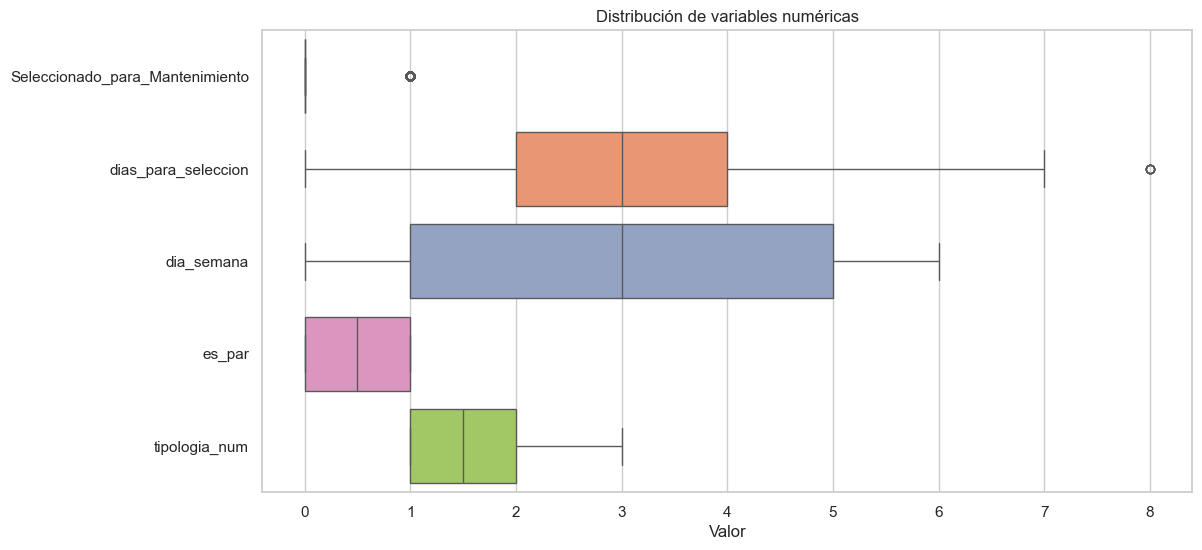

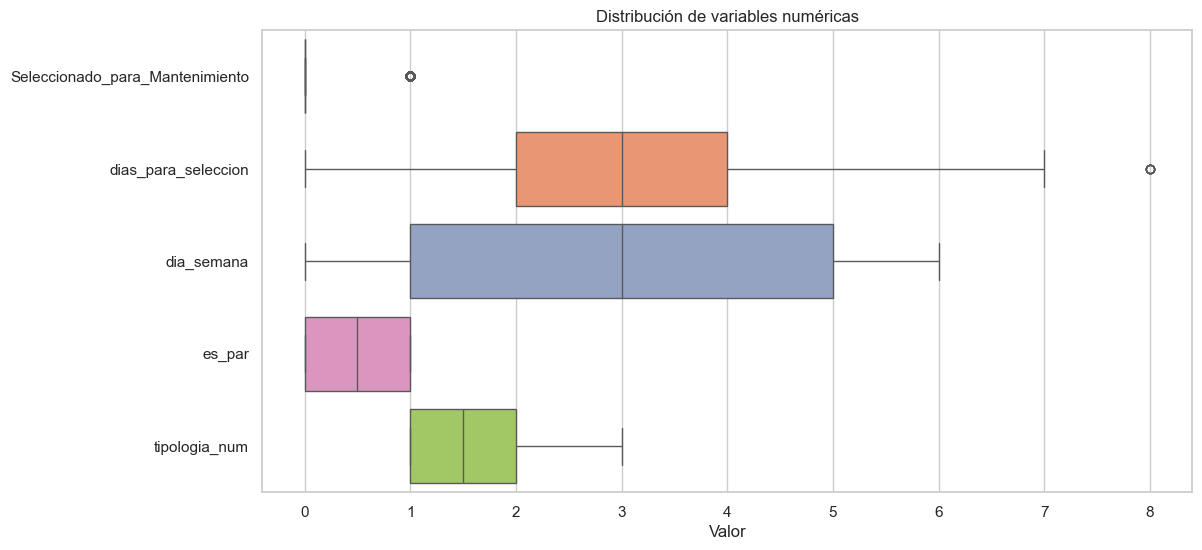

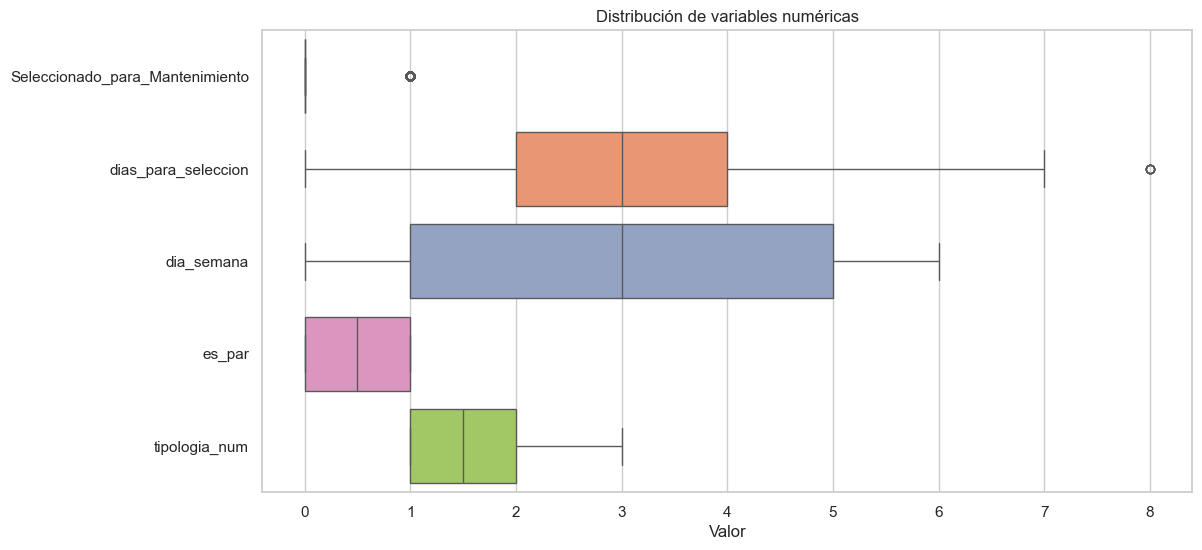

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

variables_numericas = [
    "Seleccionado_para_Mantenimiento",
    "dias_para_seleccion",
    "dia_semana",
    "es_par",
    "tipologia_num"
]

df_plot = df[variables_numericas].apply(pd.to_numeric, errors="coerce")

sns.set(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df_plot,
    orient="h",
    palette="Set2",
    ax=ax
)

ax.set_title("Distribución de variables numéricas")
ax.set_xlabel("Valor")

plt.show()


In [49]:
df['Seleccionado_para_Mantenimiento'].value_counts(dropna=False)


Seleccionado_para_Mantenimiento
0    73200
1    18300
Name: count, dtype: int64

#### Experimentación inicial y validación del modelo

Se realizaron múltiples pruebas iniciales para validar la capacidad predictiva del modelo y entender el comportamiento de las variables.

Se identificaron dos puntos críticos:

- Necesidad de evaluar el modelo bajo un enfoque temporal (train en pasado, test en futuro)

El objetivo de esta fase fue construir una primera línea base y luego mejorarla progresivamente.

In [ ]:
# definir x y
X = df.drop(columns=[
    'Seleccionado_para_Mantenimiento',
    'Número interno unidad',
    'FECHA',
    'Clase vehículo (Runner, NPR, Agrale)',
    'fecha_mant',
    'fecha_ultimo_mantenimiento',
    'dias_desde_ultimo_mantenimiento_raw',
    'dias_para_seleccion'



])

y = df['Seleccionado_para_Mantenimiento']


In [ ]:
# particionado en test y train

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[13970   670]
 [   87  3573]]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     14640
           1       0.84      0.98      0.90      3660

    accuracy                           0.96     18300
   macro avg       0.92      0.97      0.94     18300
weighted avg       0.96      0.96      0.96     18300



In [ ]:
import pandas as pd

importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': rf.feature_importances_
}).sort_values(by='importancia', ascending=False)

importancias.head(10)


,variable,importancia
3,dias_desde_ultimo_mantenimiento,0.811256
2,tipologia_num,0.186827
0,dia_semana,0.001622
1,es_par,0.000295


Se identificó que la variable más importante es `dias_desde_ultimo_mantenimiento`, lo cual tiene sentido desde el negocio: a mayor tiempo sin mantenimiento, mayor probabilidad de intervención.

También se detectó posible leakage en la variable `dias_para_seleccion`, por lo que fue eliminada.

##### Mejora: Validación temporal

Dado que el problema es temporal, se implementó un split basado en fecha para simular un escenario real de predicción.

In [ ]:
# Split temporal se entrena con el pasado, se predice el futuro
df = df.sort_values('FECHA')
train = df[df['FECHA'] < '2024-10-01']
test  = df[df['FECHA'] >= '2024-10-01']


In [ ]:

# Frecuencia histórica de mantenimiento por unidad
df['mant_ult_30d'] = (
    df.groupby('Número interno unidad')['Seleccionado_para_Mantenimiento']
      .rolling(30, min_periods=1)
      .sum()
      .reset_index(level=0, drop=True)
)


In [ ]:
# Promedio de mantenimiento por tipología
for col in ['tipologia_num_1', 'tipologia_num_2', 'tipologia_num_3']:
    df[f'freq_{col}'] = df.groupby(col)['Seleccionado_para_Mantenimiento'].transform('mean')


In [ ]:
# Promedio de mantenimiento por clase de vehículo
df['freq_clase'] = df.groupby('Clase vehículo (xxxx, xxx, xx)')['Seleccionado_para_Mantenimiento'].transform('mean')


In [ ]:
# Entrenamiento
features = [
    'es_par',
    # 'dia_semana',
    'mant_ult_30d',
    'tipologia_num_1',
    'tipologia_num_2',
    'tipologia_num_3',
    'freq_tipologia_num_1',
    'freq_tipologia_num_2',
    'freq_tipologia_num_3',
    'freq_clase',
    # 'dias_para_seleccion'
]

target = 'Seleccionado_para_Mantenimiento'


In [ ]:
df = df.sort_values('FECHA')

train = df[df['FECHA'] < '2024-10-01']
test  = df[df['FECHA'] >= '2024-10-01']

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Ajustamos class_weight para la clase minoritaria
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.58      0.73     18400
           1       0.37      1.00      0.54      4600

    accuracy                           0.66     23000
   macro avg       0.68      0.79      0.64     23000
weighted avg       0.87      0.66      0.69     23000



El modelo logra capturar prácticamente todos los casos positivos (recall alto), alineándose con el objetivo de minimizar falsos negativos.

Sin embargo, esto incrementa los falsos positivos, lo cual es aceptable dado el contexto operativo.

In [ ]:
probs = rf.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1 (mantener)


In [ ]:
import numpy as np

threshold = 0.65  # probar valores entre 0.5 y 0.9
y_pred_adj = (probs >= threshold).astype(int)


In [ ]:

print(classification_report(y_test, y_pred_adj))


              precision    recall  f1-score   support

           0       0.90      0.78      0.83     18400
           1       0.42      0.64      0.51      4600

    accuracy                           0.75     23000
   macro avg       0.66      0.71      0.67     23000
weighted avg       0.80      0.75      0.77     23000



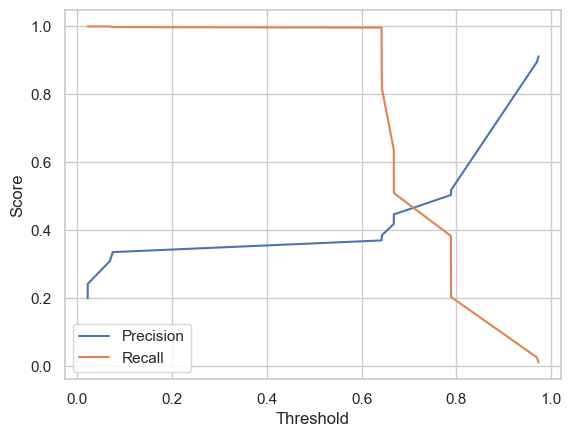

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()


## Modelo final
## 🎯 Optimización enfocada en la clase crítica

Dado que el costo principal del problema es no detectar vehículos que requieren mantenimiento (falsos negativos), se ajustó el modelo para priorizar el recall de la clase 1.

Esto implica aceptar una degradación en la capacidad de identificar correctamente la clase 0, a cambio de maximizar la detección de casos críticos.

##### Transformación y agregación

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'data\mantenimiento_vehiculos_2024.csv')


#  Preparar fechas y ordenar
# -----------------------------
df['FECHA'] = pd.to_datetime(df['FECHA'])
df = df.sort_values(['Número interno unidad', 'FECHA'])

#  Mantenimiento histórico
# -----------------------------
df['evento_mant'] = df['Seleccionado_para_Mantenimiento']

df['fecha_mant'] = df['FECHA'].where(df['evento_mant'] == 1)
df['fecha_mant_ffill'] = df.groupby('Número interno unidad')['fecha_mant'].ffill()
df['fecha_penultimo'] = df.groupby('Número interno unidad')['fecha_mant'].shift(1).ffill()

df['dias_desde_ultimo_mantenimiento_raw'] = (
    df['FECHA'] - df['fecha_mant_ffill']
).dt.days.fillna(0).clip(lower=0)

df['dias_desde_penultimo'] = (
    df.groupby('Número interno unidad')['dias_desde_ultimo_mantenimiento_raw']
      .shift(1)
      .fillna(0)
)

#  Target futuro a 3 días
# -----------------------------
N = 3
df['y_futuro'] = (
    df.groupby('Número interno unidad')['Seleccionado_para_Mantenimiento']
      .shift(-1)
      .rolling(window=N, min_periods=1)
      .max()
      .reset_index(level=0, drop=True)
)
df['y_futuro'] = df['y_futuro'].fillna(0).astype(int)

#  Features de calendario
# -----------------------------
df['dia_semana'] = df['FECHA'].dt.weekday
df['es_fin_semana'] = df['dia_semana'].isin([5, 6]).astype(int)
df['semana_anio'] = df['FECHA'].dt.isocalendar().week.astype(int)
df['mes'] = df['FECHA'].dt.month

#  Estadísticas históricas de mantenimiento
# -----------------------------
df['intervalo_real'] = df.groupby('Número interno unidad')['fecha_mant'].diff().dt.days
df['prom_intervalo_hist'] = df.groupby('Número interno unidad')['intervalo_real'].expanding().mean().reset_index(level=0, drop=True)
df['std_intervalo_hist'] = df.groupby('Número interno unidad')['intervalo_real'].expanding().std().reset_index(level=0, drop=True)

df[['prom_intervalo_hist', 'std_intervalo_hist']] = df[['prom_intervalo_hist', 'std_intervalo_hist']].fillna(0)

df['mnts_ult_30d'] = df.groupby('Número interno unidad')['evento_mant'].rolling(window=30, min_periods=1).sum().reset_index(level=0, drop=True)
df['mnts_ult_60d'] = df.groupby('Número interno unidad')['evento_mant'].rolling(window=60, min_periods=1).sum().reset_index(level=0, drop=True)

df['ratio_reciente_vs_hist'] = df['mnts_ult_30d'] / (df['prom_intervalo_hist'] + 1)

#  Definir features y target
# -----------------------------
features = [
    'tipologia_num',
    'dia_semana',
    'es_fin_semana',
    'semana_anio',
    'mes',
    'dias_desde_penultimo',
    'prom_intervalo_hist',
    'std_intervalo_hist',
    'mnts_ult_30d',
    'mnts_ult_60d',
    'ratio_reciente_vs_hist'
]

X = df[features]
y = df['y_futuro']


##### División del df y entrenamiento

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_recall_curve, auc

#  Dividir por fechas
# -----------------------------
# Fecha de corte para test
fecha_test = '2024-10-01'
# Fecha de corte para validation
fecha_val = '2024-09-01'

X_train = X[df['FECHA'] < fecha_val]
y_train = y[df['FECHA'] < fecha_val]

X_val = X[(df['FECHA'] >= fecha_val) & (df['FECHA'] < fecha_test)]
y_val = y[(df['FECHA'] >= fecha_val) & (df['FECHA'] < fecha_test)]

X_test = X[df['FECHA'] >= fecha_test]
y_test = y[df['FECHA'] >= fecha_test]

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# Crear pipeline
# -----------------------------
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),  # escalado en caso de utilizar otros modelos sensibles
    ('model', RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

#  Entrenar
# -----------------------------
pipeline.fit(X_train, y_train)

# Evaluación en validation
# -----------------------------
y_val_pred = pipeline.predict(X_val)
y_val_prob = pipeline.predict_proba(X_val)[:, 1]

print("📌 Classification report (Validation set):")
print(classification_report(y_val, y_val_pred))

precision, recall, _ = precision_recall_curve(y_val, y_val_prob)
auc_pr = auc(recall, precision)
print(f"AUC-PR (Validation set): {auc_pr:.3f}")

# Evaluación en test
# -----------------------------
y_test_pred = pipeline.predict(X_test)
y_test_prob = pipeline.predict_proba(X_test)[:, 1]

print("📌 Classification report (Test set):")
print(classification_report(y_test, y_test_pred))

precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
auc_pr = auc(recall, precision)
print(f"AUC-PR (Test set): {auc_pr:.3f}")


Shapes:
Train: (61000, 11) (61000,)
Validation: (7500, 11) (7500,)
Test: (23000, 11) (23000,)
📌 Classification report (Validation set):
              precision    recall  f1-score   support

           0       0.29      0.01      0.02      2512
           1       0.66      0.99      0.79      4988

    accuracy                           0.66      7500
   macro avg       0.48      0.50      0.41      7500
weighted avg       0.54      0.66      0.53      7500

AUC-PR (Validation set): 0.671
📌 Classification report (Test set):
              precision    recall  f1-score   support

           0       0.08      0.01      0.02      3087
           1       0.86      0.98      0.92     19913

    accuracy                           0.85     23000
   macro avg       0.47      0.50      0.47     23000
weighted avg       0.76      0.85      0.80     23000

AUC-PR (Test set): 0.859


El modelo presenta un recall cercano al 100% en la clase prioritaria, lo que significa que prácticamente todos los vehículos que requieren mantenimiento son detectados.

Aunque esto genera un incremento en falsos positivos, este comportamiento es consistente con la estrategia del negocio, donde es preferible intervenir un vehículo innecesariamente a no detectar uno crítico.

El modelo mantiene un desempeño consistente en datos fuera de muestra (validación y test), preservando un alto recall en la clase prioritaria. Esto confirma su capacidad de generalización en un escenario operativo real, sin degradaciones significativas en la detección de casos críticos.

In [ ]:
# Guardar modelo
#----------------
import joblib

joblib.dump(pipeline, "../train_model/modelo_rf_mantenimiento.pkl")